In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy
import glob


# Data Processing and PLotting

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD', 'dX', 'sigma_dX', 'dY', 'sigma_dY']
    cols_widths = [(0,11),(12,22),(23,33),(34,44),(45,55)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [3]:
files = glob.glob('nut_*.dat')

In [5]:
dfs = {}

for file in files:
    method_name = file.split('_')[1].split('.')[0]
    df = process_data(file)
    dfs[method_name] = df

<Figure size 1500x800 with 0 Axes>

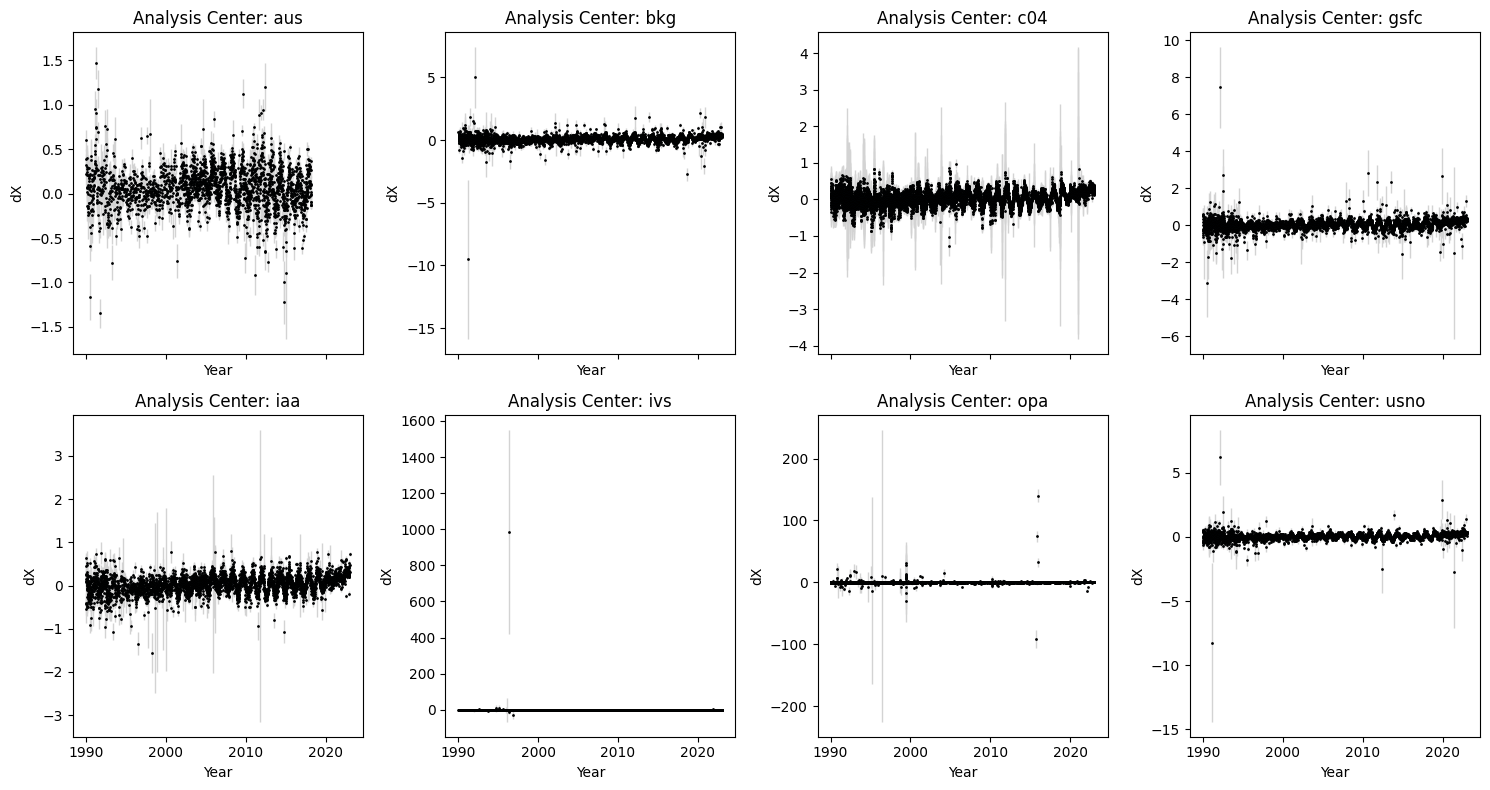

In [6]:
# Figure dX data plot for all methods
plt.figure(figsize=(15, 8))
plt.subplots_adjust(hspace=0.2)

# Create subplots
ncols = 4
nrows = len(dfs) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

# Iterate through each method in the dict
for i, (method, df) in enumerate(dfs.items()):
    # Plot with BY converted from MJD
    axes[i].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dX'], yerr=df['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 

    axes[i].set_title(f'Analysis Center: {method}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('dX')

plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

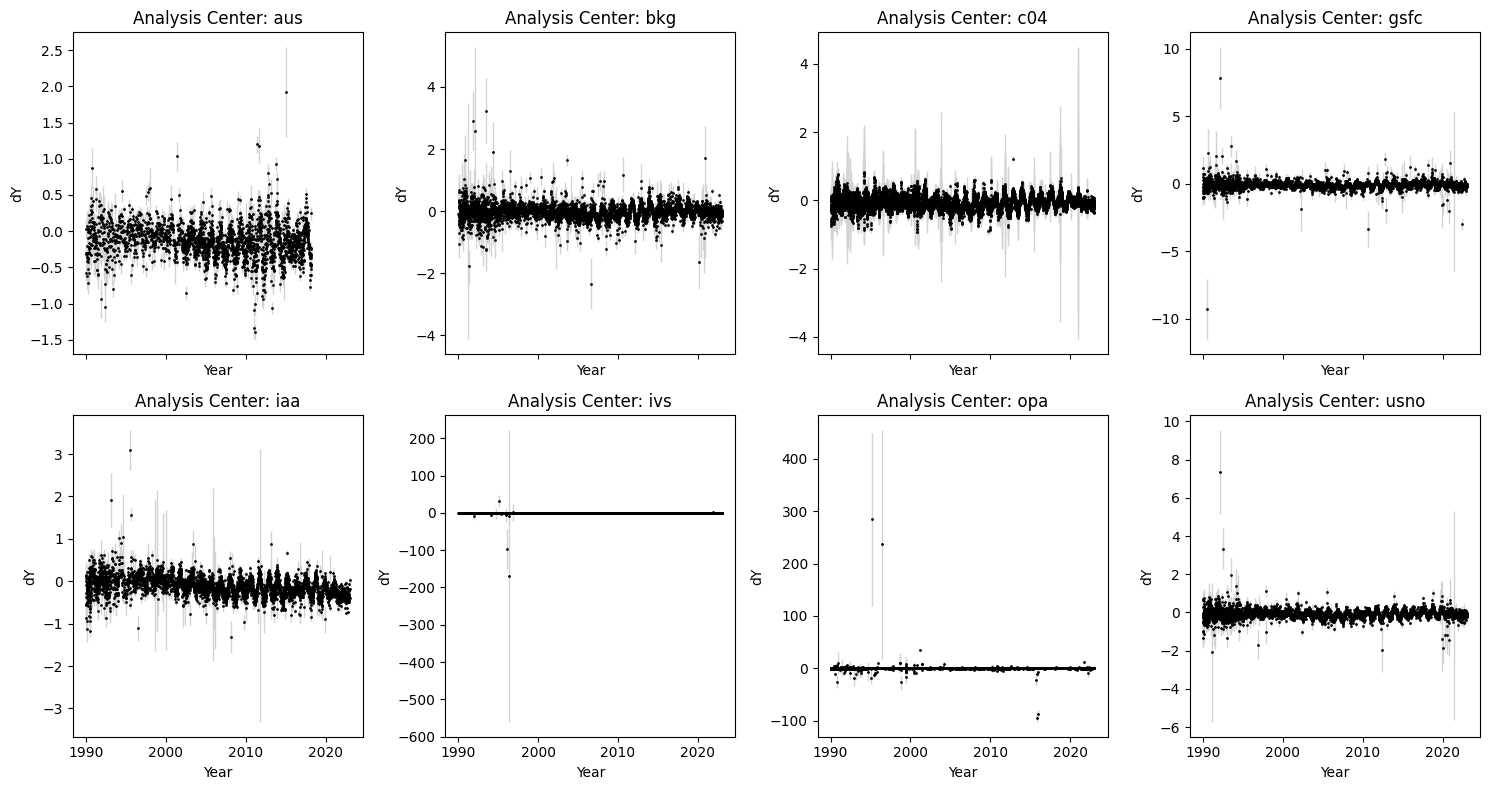

In [7]:
# Figure dX data plot for all methods
plt.figure(figsize=(15, 8))
plt.subplots_adjust(hspace=0.2)

# Create subplots
ncols = 4
nrows = len(dfs) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

# Iterate through each method in the dict
for i, (method, df) in enumerate(dfs.items()):
    # Plot with BY converted from MJD
    axes[i].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dY'], yerr=df['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 

    axes[i].set_title(f'Analysis Center: {method}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan - dX

In [52]:
allanstds_dX = {}  

for method, df in dfs.items():
    # Calculate allan std dev
    tau, allanstd = allanself.oadev(df['dX'].values,df['MJD'].values,df['sigma_dX'].values)

    allanstds_dX[method] = {'tau': tau, 'allanstd': allanstd}

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\Nutation\allanself.py:393: RuntimeWarning: invalid value encountered in scalar divide
  allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))


In [57]:
for method, result in allanstds_dX.items():
    filename = f"allanstd_dX_{method}.txt"
    np.savetxt(filename, np.column_stack((result['tau'], result['allanstd'])), header="Tau Allanstd", comments="", delimiter='\t')

In [59]:
allanstds_dX['opa']['allanstd']

array([0.06216418, 0.05354801, 0.04936366, ..., 0.02671877, 0.0267371 ,
       0.02675543])

In [98]:
ci_dX = {}  

for method, df in dfs.items():
    # Calculate CI
    ci_low, ci_high = allanself.confidence_int(df['dX'].values,df['sigma_dX'].values,allanstds_dX[method]['allanstd'],modified=False,overlapping=True,devtype='allan')

    ci_dX[method] = {'low': ci_low, 'high': ci_high}

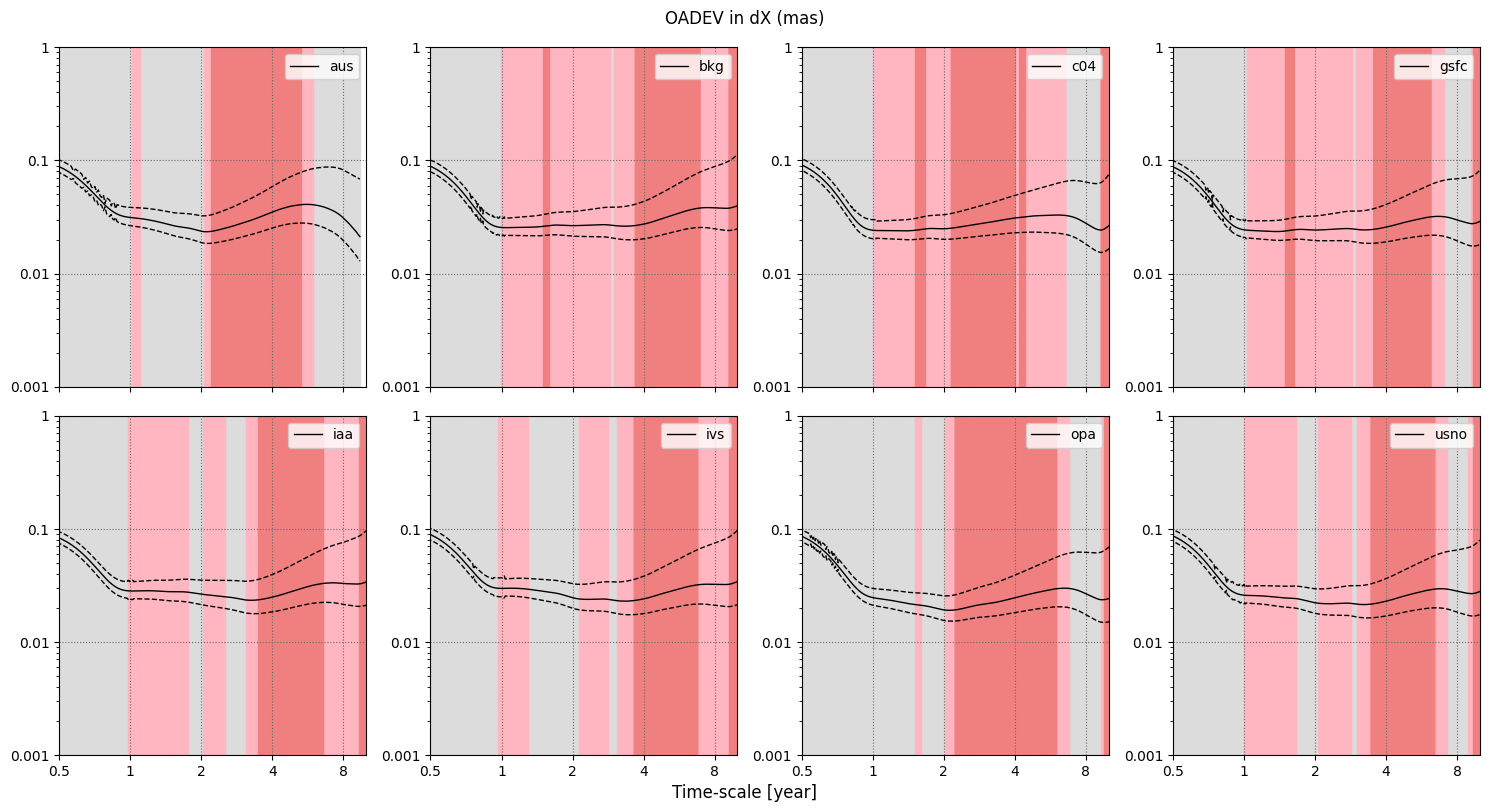

In [111]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i, (method, result) in enumerate(allanstds_dX.items()):
    tau, allanstd = result['tau'], result['allanstd']
    tau_year = [t/365.242198781 for t in tau]
    # Calculate the slopes
    slopes = np.diff(np.log10(allanstd)) / np.diff(np.log10(tau))

    # Plot allan_std
    axes[i].plot(tau_year, allanstd, color = 'black', label=f'{method}', linewidth=1)

    # Color background according to the slopes / noise type
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(slopes < 0.25), color='gainsboro', linewidth=1, zorder=1)
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(-0.25 <= slopes) & (slopes <= 0.25), color='lightpink', linewidth=1)
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(slopes > 0.25), color='lightcoral', step='mid', linewidth=1)

    # Plot confidence interval
    axes[i].plot(tau_year, ci_dX[method]['low'],color='black',linestyle='dashed',linewidth=1)
    axes[i].plot(tau_year, ci_dX[method]['high'],color='black',linestyle='dashed',linewidth=1)


    # Plot settings
    axes[i].set_yscale('log')
    axes[i].set_xscale('log', base=2)
    axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    axes[i].set_ylim(0.001, 1)
    axes[i].set_xlim(0.5, 10)
    axes[i].grid(color='dimgray', linestyle='dotted')
    axes[i].legend()
fig.text(0.5, 0.001, 'Time-scale [year]', ha='center', va='center', fontsize=12)
plt.suptitle('OADEV in dX (mas)')
plt.tight_layout()
plt.show()

# Allanstd - dY

In [8]:
allanstds_dY = {}  

for method, df in dfs.items():
    # Calculate allan std dev
    tau, allanstd = allanself.oadev(df['dY'].values,df['MJD'].values,df['sigma_dY'].values)

    allanstds_dY[method] = {'tau': tau, 'allanstd': allanstd}

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\Nutation\allanself.py:393: RuntimeWarning: invalid value encountered in scalar divide
  allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))


In [9]:
for method, result in allanstds_dY.items():
    filename = f"allanstd_dY_{method}.txt"
    np.savetxt(filename, np.column_stack((result['tau'], result['allanstd'])), header="Tau Allanstd", comments="", delimiter='\t')

In [10]:
allanstds_dY['opa']['allanstd']

array([0.07208117, 0.06857172, 0.06586631, ..., 0.0186238 , 0.01861858,
       0.01861331])

In [11]:
ci_dY = {}  

for method, df in dfs.items():
    # Calculate CI
    ci_low, ci_high = allanself.confidence_int(df['dY'].values,df['sigma_dY'].values,allanstds_dY[method]['allanstd'],modified=False,overlapping=True,devtype='allan')

    ci_dY[method] = {'low': ci_low, 'high': ci_high}

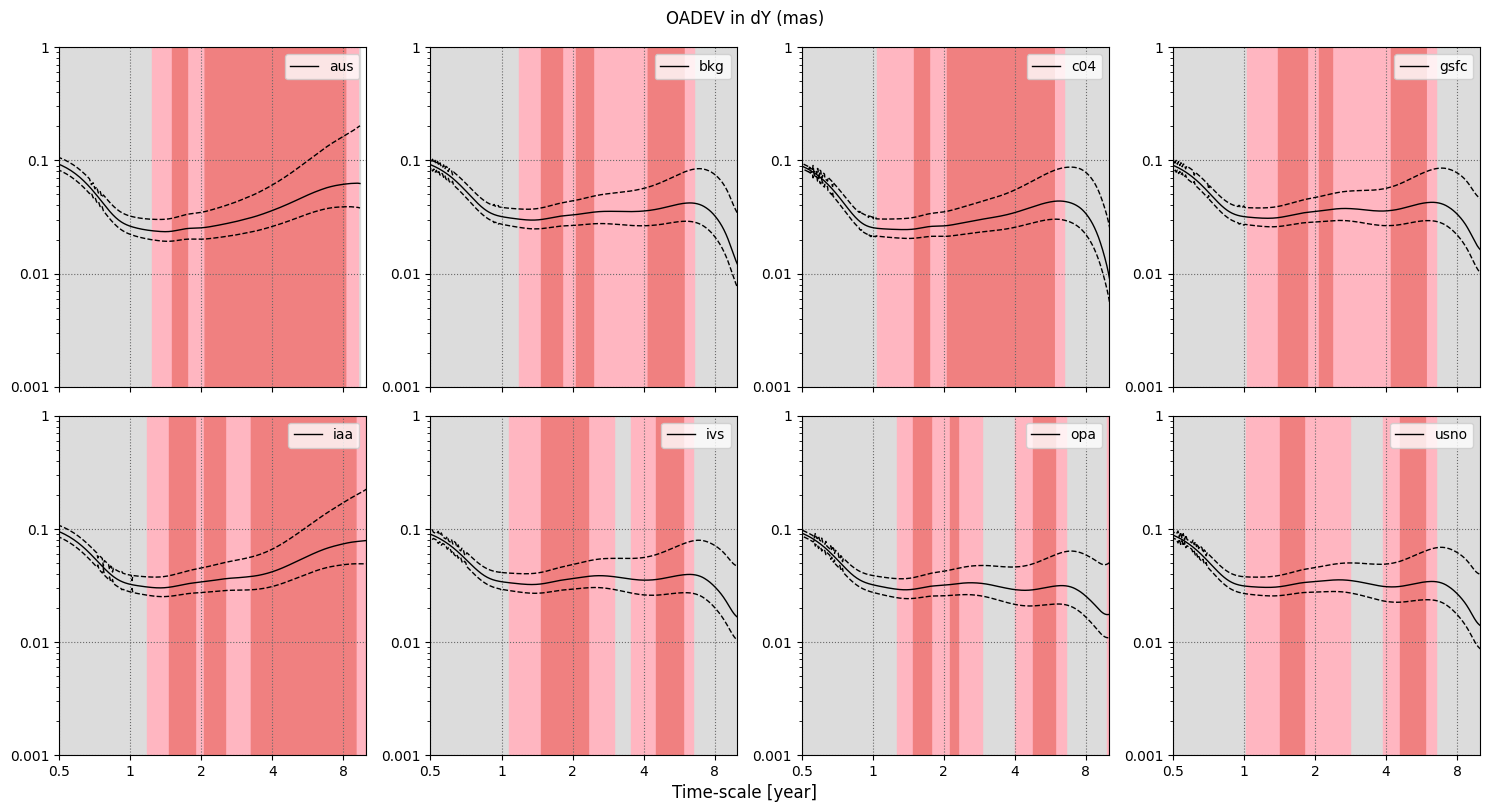

In [12]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i, (method, result) in enumerate(allanstds_dY.items()):
    tau, allanstd = result['tau'], result['allanstd']
    tau_year = [t/365.242198781 for t in tau]
    # Calculate the slopes
    slopes = np.diff(np.log10(allanstd)) / np.diff(np.log10(tau))

    # Plot allan_std
    axes[i].plot(tau_year, allanstd, color = 'black', label=f'{method}', linewidth=1)

    # Color background according to the slopes / noise type
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(slopes < 0.25), color='gainsboro', linewidth=1, zorder=1)
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(-0.25 <= slopes) & (slopes <= 0.25), color='lightpink', linewidth=1)
    axes[i].fill_between(tau_year[1:], 0, 10**5, where=(slopes > 0.25), color='lightcoral', step='mid', linewidth=1)

    # Plot confidence interval
    axes[i].plot(tau_year, ci_dY[method]['low'],color='black',linestyle='dashed',linewidth=1)
    axes[i].plot(tau_year, ci_dY[method]['high'],color='black',linestyle='dashed',linewidth=1)


    # Plot settings
    axes[i].set_yscale('log')
    axes[i].set_xscale('log', base=2)
    axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    axes[i].set_ylim(0.001, 1)
    axes[i].set_xlim(0.5, 10)
    axes[i].grid(color='dimgray', linestyle='dotted')
    axes[i].legend()
fig.text(0.5, 0.001, 'Time-scale [year]', ha='center', va='center', fontsize=12)
plt.suptitle('OADEV in dY (mas)')
plt.tight_layout()
plt.show()